In [123]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
import time

# --- 1. Load & Preprocessing Data ---
print("Lagi nyiapin dataset...")
df = pd.read_csv('/content/ringkasan_penjualan_harian.csv')
df['tanggal'] = pd.to_datetime(df['tanggal'], format='%d/%m/%Y')
# Pastikan data urut berdasarkan waktu biar ga berantakan
df = df.sort_values('tanggal').reset_index(drop=True)

# Ambil info hari buat dijadiin fitur (Senin=0, Minggu=6)
df['day_of_week'] = df['tanggal'].dt.dayofweek
df['is_event'] = df['is_event'].astype(int)

# Totalin semua penjualan produk
product_cols = [col for col in df.columns if col not in ['tanggal', 'is_event', 'day_of_week']]
df['total_penjualan'] = df[product_cols].sum(axis=1)

# OHE buat hari biar model nggak ngira hari itu angka ordinal (minggu bukan berarti lebih besar dari senin)
encoder_hari = OneHotEncoder(sparse_output=False)
hari_encoded = encoder_hari.fit_transform(df[['day_of_week']])

# Normalize target penjualan pake Z-Score
sales_data = df['total_penjualan'].values.reshape(-1, 1)
scaler_sales = StandardScaler()

# Bagi data train & test (80-20)
train_size = int(len(sales_data) * 0.8)

# Hati-hati data leakage: fit scaler cuma di data train aja!
train_sales_scaled = scaler_sales.fit_transform(sales_data[:train_size])
test_sales_scaled = scaler_sales.transform(sales_data[train_size:])

# Gabungin fitur buat bagian Encoder (Histori Sales + Hari)
train_enc_features = np.hstack((train_sales_scaled, hari_encoded[:train_size]))
test_enc_features = np.hstack((test_sales_scaled, hari_encoded[train_size:]))

# Gabungin fitur buat bagian Decoder (Event + Hari)
event_data = df['is_event'].values.reshape(-1, 1)
train_dec_features = np.hstack((event_data[:train_size], hari_encoded[:train_size]))
test_dec_features = np.hstack((event_data[train_size:], hari_encoded[train_size:]))

# --- 2. Bikin Sequence Time-Series ---
# Fungsi buat motong-motong data jadi sequence (multistep)
def create_multistep_data(enc_feat, dec_feat, sales_scaled, look_back=14, forecast_horizon=7):
    X_enc, X_dec, y = [], [], []
    for i in range(len(sales_scaled) - look_back - forecast_horizon + 1):
        # Data histori 14 hari ke belakang
        X_enc.append(enc_feat[i:(i + look_back)])
        # Konteks 7 hari ke depan (hari apa aja, ada event ga)
        X_dec.append(dec_feat[(i + look_back):(i + look_back + forecast_horizon)])
        # Target penjualannya
        y.append(sales_scaled[(i + look_back):(i + look_back + forecast_horizon)])
    return np.array(X_enc), np.array(X_dec), np.array(y)

# Set window size: liat 14 hari, tebak 7 hari
look_back = 14
forecast_horizon = 7

X_enc_train, X_dec_train, y_train = create_multistep_data(train_enc_features, train_dec_features, train_sales_scaled, look_back, forecast_horizon)
X_enc_test, X_dec_test, y_test = create_multistep_data(test_enc_features, test_dec_features, test_sales_scaled, look_back, forecast_horizon)

print(f"Shape X_enc_train: {X_enc_train.shape}")
print(f"Shape y_train: {y_train.shape}\n")

# --- 3. Build Model Seq2Seq & Custom Loss ---
print("Setup arsitektur model Seq2Seq...")
def build_7day_seq2seq(enc_timesteps, enc_features, dec_timesteps, dec_features):
    # Bagian Encoder
    enc_inputs = Input(shape=(enc_timesteps, enc_features), name='encoder_input')
    enc_gru, state_h = GRU(64, return_state=True, name='encoder_gru')(enc_inputs)

    # Bagian Decoder
    dec_inputs = Input(shape=(dec_timesteps, dec_features), name='decoder_input')
    dec_gru = GRU(64, return_sequences=True, name='decoder_gru')
    dec_outputs = dec_gru(dec_inputs, initial_state=state_h)

    dec_outputs = Dropout(0.2)(dec_outputs)
    outputs = Dense(1, activation='linear', name='output_layer')(dec_outputs)

    model = Model(inputs=[enc_inputs, dec_inputs], outputs=outputs)
    return model

model = build_7day_seq2seq(
    enc_timesteps=X_enc_train.shape[1], enc_features=X_enc_train.shape[2],
    dec_timesteps=X_dec_train.shape[1], dec_features=X_dec_train.shape[2]
)

# Custom Asymmetric Huber Loss
# Note: tf.cast ditambahin biar TF ga ngambek gara-gara beda tipe data float32 (pred) vs float64 (true)
def asymmetric_huber_loss(penalty_factor=10.0, delta=1.0):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, dtype=y_pred.dtype)
        error = y_true - y_pred

        is_small_error = tf.abs(error) <= delta
        small_error_loss = tf.square(error) / 2.0
        big_error_loss = delta * (tf.abs(error) - (delta / 2.0))

        base_loss = tf.where(is_small_error, small_error_loss, big_error_loss)
        asymmetric_penalty = tf.where(error > 0, penalty_factor * base_loss, base_loss)
        return tf.reduce_mean(asymmetric_penalty)
    return loss

# --- 4. Custom Training Loop (tf.GradientTape) ---
print("Mulai proses training...")
batch_size = 16

# Convert dataset ke float32 dulu biar ringan di memori
train_dataset = tf.data.Dataset.from_tensor_slices((
    (X_enc_train.astype(np.float32), X_dec_train.astype(np.float32)),
    y_train.astype(np.float32)
)).batch(batch_size)

test_dataset = tf.data.Dataset.from_tensor_slices((
    (X_enc_test.astype(np.float32), X_dec_test.astype(np.float32)),
    y_test.astype(np.float32)
)).batch(batch_size)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn = asymmetric_huber_loss(penalty_factor=15.0)

# Setup tracker buat nyimpen nilai metrik selama epoch berjalan
train_loss_tracker = tf.keras.metrics.Mean(name='train_loss')
val_loss_tracker = tf.keras.metrics.Mean(name='val_loss')
val_mae_tracker = tf.keras.metrics.MeanAbsoluteError(name='val_mae')

@tf.function
def train_step(enc_inputs, dec_inputs, targets):
    with tf.GradientTape() as tape:
        # Pake training=True biar layer Dropout aktif pas training
        predictions = model([enc_inputs, dec_inputs], training=True)
        loss = loss_fn(targets, predictions)

    # Hitung gradien & update bobot
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    train_loss_tracker(loss)

@tf.function
def test_step(enc_inputs, dec_inputs, targets):
    # training=False biar Dropout mati pas testing/validasi
    predictions = model([enc_inputs, dec_inputs], training=False)
    loss = loss_fn(targets, predictions)
    val_loss_tracker(loss)
    val_mae_tracker(targets, predictions)

# Parameter training
epochs = 100
patience = 15
best_val_loss = float('inf')
patience_counter = 0
best_weights = None
history = {'loss': [], 'val_loss': []}

for epoch in range(epochs):
    start_time = time.time()

    # Jangan lupa reset metrik di tiap awal epoch
    train_loss_tracker.reset_state()
    val_loss_tracker.reset_state()
    val_mae_tracker.reset_state()

    # Loop buat data train
    for (enc_batch, dec_batch), target_batch in train_dataset:
        train_step(enc_batch, dec_batch, target_batch)

    # Loop buat data validasi
    for (enc_batch, dec_batch), target_batch in test_dataset:
        test_step(enc_batch, dec_batch, target_batch)

    # Ambil nilai rata-rata metrik di epoch ini
    epoch_train_loss = train_loss_tracker.result().numpy()
    epoch_val_loss = val_loss_tracker.result().numpy()

    history['loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    Waktu_epoch = time.time() - start_time

    print(f"Epoch {epoch+1:03d}/{epochs} - {Waktu_epoch:.1f}s - loss: {epoch_train_loss:.4f} - val_loss: {epoch_val_loss:.4f}")

    # Logika Manual Early Stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        best_weights = model.get_weights() # Simpan model terbaik sejauh ini
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n[Info] Udah ga ada improvement selama {patience} epoch. Stop training deh.")
            print("Ngere-store bobot model ke versi yang paling bagus...")
            model.set_weights(best_weights)
            break

Lagi nyiapin dataset...
Shape X_enc_train: (355, 14, 8)
Shape y_train: (355, 7, 1)

Setup arsitektur model Seq2Seq...
Mulai proses training...
Epoch 001/100 - 10.9s - loss: 2.1737 - val_loss: 3.7810
Epoch 002/100 - 0.1s - loss: 2.0170 - val_loss: 3.6220
Epoch 003/100 - 0.1s - loss: 1.9635 - val_loss: 3.5326
Epoch 004/100 - 0.1s - loss: 1.9211 - val_loss: 3.4128
Epoch 005/100 - 0.1s - loss: 1.8699 - val_loss: 3.2856
Epoch 006/100 - 0.1s - loss: 1.8121 - val_loss: 3.1365
Epoch 007/100 - 0.1s - loss: 1.7659 - val_loss: 2.9672
Epoch 008/100 - 0.1s - loss: 1.6980 - val_loss: 2.7734
Epoch 009/100 - 0.1s - loss: 1.6347 - val_loss: 2.5698
Epoch 010/100 - 0.1s - loss: 1.5504 - val_loss: 2.3372
Epoch 011/100 - 0.1s - loss: 1.4799 - val_loss: 2.1123
Epoch 012/100 - 0.1s - loss: 1.4323 - val_loss: 1.8702
Epoch 013/100 - 0.1s - loss: 1.3443 - val_loss: 1.6506
Epoch 014/100 - 0.1s - loss: 1.2666 - val_loss: 1.4332
Epoch 015/100 - 0.1s - loss: 1.2109 - val_loss: 1.2339
Epoch 016/100 - 0.1s - loss: 1.

Mulai memprediksi data test...

--- Hasil Evaluasi di Test Set ---
Rata-rata error absolut (MAE)  : 1.54 unit/penjualan
Root Mean Squared Error (RMSE) : 1.88 unit/penjualan

Bikin plot kontinu...


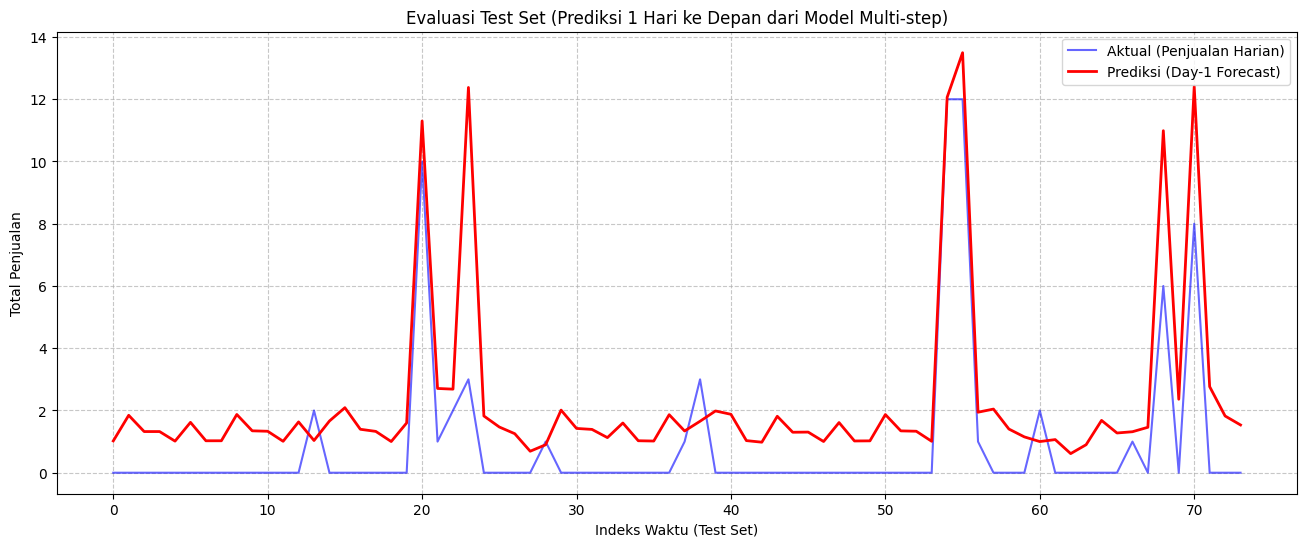

Bikin plot trajektori 7 harian...


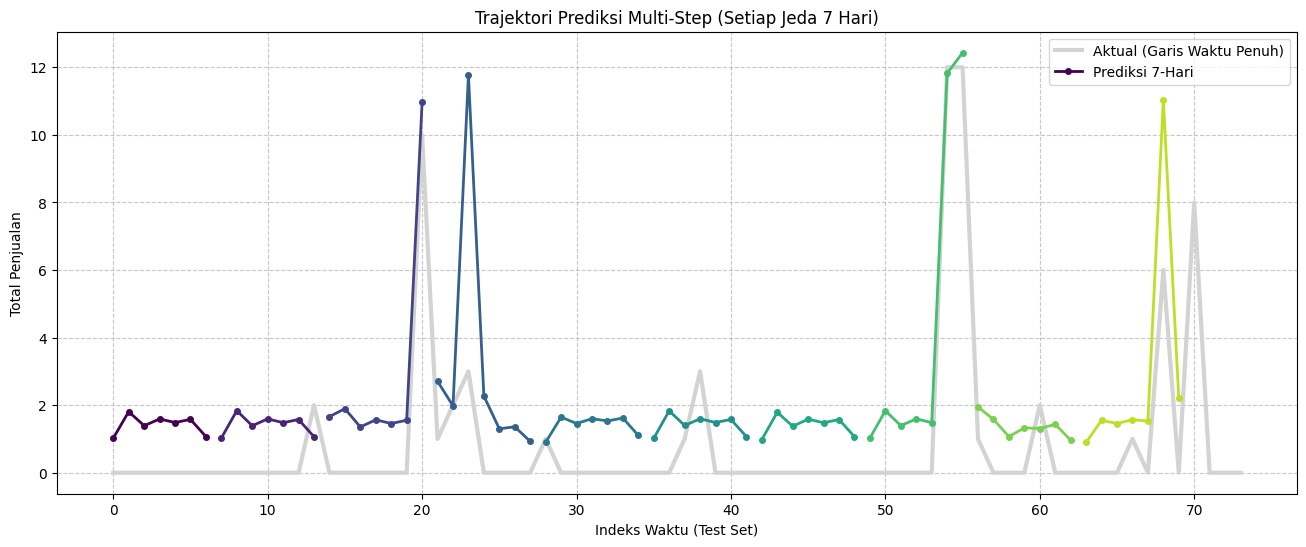

In [124]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. Prediksi & Balikin Skala (Inverse Transform) ---
print("Mulai memprediksi data test...")
# Hasil prediksi bakal punya dimensi (jumlah_sampel, 7, 1)
predictions_scaled = model.predict([X_enc_test, X_dec_test], verbose=0)

# Balikin skalanya dari Z-score ke nilai penjualan aslinya.
# Karena scaler cuma mau nerima array 2D, kita gepengin dulu (flatten),
# baru di-inverse, trus balikin lagi ke dimensinya semula.
predictions_2d = predictions_scaled.reshape(-1, 1)
predictions_inv_2d = scaler_sales.inverse_transform(predictions_2d)
predictions = predictions_inv_2d.reshape(predictions_scaled.shape[0], forecast_horizon)

# Lakuin hal yang sama persis buat data aktualnya (y_test)
y_test_2d = y_test.reshape(-1, 1)
y_test_inv_2d = scaler_sales.inverse_transform(y_test_2d)
y_test_actual = y_test_inv_2d.reshape(y_test.shape[0], forecast_horizon)

# --- 2. Hitung Metrik Evaluasi ---
# Ngitung rata-rata error model pake MAE (absolut) dan RMSE (kuadrat)
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

print(f"\n--- Hasil Evaluasi di Test Set ---")
print(f"Rata-rata error absolut (MAE)  : {mae:.2f} unit/penjualan")
print(f"Root Mean Squared Error (RMSE) : {rmse:.2f} unit/penjualan\n")

# --- 3. Visualisasi 1: Plot Kontinu (Cuma nge-plot hari ke-1 dari tiap prediksi) ---
print("Bikin plot kontinu...")
# Kita ambil indeks 0 (hari pertama aja) dari tiap window tebakan 7 hari
# buat ngeliat gimana tren garis nyambungnya
aktual_kontinu = y_test_actual[:, 0]
prediksi_kontinu = predictions[:, 0]

plt.figure(figsize=(16, 6))
plt.plot(aktual_kontinu, label='Aktual (Penjualan Harian)', color='blue', alpha=0.6)
plt.plot(prediksi_kontinu, label='Prediksi (Day-1 Forecast)', color='red', linewidth=2)
plt.title('Evaluasi Test Set (Prediksi 1 Hari ke Depan dari Model Multi-step)')
plt.xlabel('Indeks Waktu (Test Set)')
plt.ylabel('Total Penjualan')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- 4. Visualisasi 2: Trajektori Multi-Step (Liat prediksi 7 harian sekaligus) ---
print("Bikin plot trajektori 7 harian...")
plt.figure(figsize=(16, 6))

# Jadikan garis data aktual penuh sebagai background (warna abu-abu biar ga nabrak warnanya)
plt.plot(aktual_kontinu, label='Aktual (Garis Waktu Penuh)', color='lightgray', linewidth=3)

# Biar plotnya ga terlalu kusut/keramean, kita gambar tebakan 7 harinya setiap kelipatan 7 aja
interval = 7
colors = plt.cm.viridis(np.linspace(0, 1, len(range(0, len(predictions), interval))))

for idx, color in zip(range(0, len(predictions), interval), colors):
    # Tentukan rentang sumbu X buat 7 hari ke depan
    x_axis = range(idx, idx + forecast_horizon)

    # Cek biar trajektorinya ga bablas ngelewatin batas maksimal grafik data aktual
    if idx + forecast_horizon <= len(aktual_kontinu):
        plt.plot(x_axis, predictions[idx, :], marker='o', markersize=4,
                 color=color, linewidth=2, label='Prediksi 7-Hari' if idx == 0 else "")

plt.title('Trajektori Prediksi Multi-Step (Setiap Jeda 7 Hari)')
plt.xlabel('Indeks Waktu (Test Set)')
plt.ylabel('Total Penjualan')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [125]:
# Save pake format .keras
model_filename = 'seq2seq_sales_forecast.keras'
model.save(model_filename)

print(f"Mantap! Model udah aman tersimpan sebagai '{model_filename}' 🚀")

Mantap! Model udah aman tersimpan sebagai 'seq2seq_sales_forecast.keras' 🚀


In [127]:
import pandas as pd
import numpy as np

# --- 1. Load Data Statis (BOM) & Data Min-Max ---
print("Narik data statis dan min-max...")
static_df = pd.read_csv('data_static_qty_normalized.csv')
minmax_df = pd.read_csv('min_max_dataset_full.csv', index_col=0) # Index 0 itu buat kolom 'MIN' dan 'MAX'

# Ambil list nama bahan baku (semua kolom kecuali 'Produk')
bahan_baku_cols = [col for col in static_df.columns if col != 'Produk']

# --- 2. Fungsi Denormalisasi (Balikin ke Nilai Asli) ---
def denormalize_static_data(static_data, minmax_data, cols):
    # Dicopy dulu biar dataframe aslinya aman ga kerubah
    denorm_df = static_data.copy()

    for col in cols:
        min_val = minmax_data.loc['MIN', col]
        max_val = minmax_data.loc['MAX', col]

        # Rumus standar denormalisasi: Aktual = (Normalisasi * (Max - Min)) + Min
        denorm_df[col] = (denorm_df[col] * (max_val - min_val)) + min_val

        # Dibulatkan 2 angka di belakang koma aja biar rapi
        denorm_df[col] = np.round(denorm_df[col], 2)

    return denorm_df

# Bikin dataframe bahan baku yang ukurannya udah balik ke nilai aslinya
actual_static_df = denormalize_static_data(static_df, minmax_df, bahan_baku_cols)

# --- 3. Fungsi Hitung Kebutuhan Total Bahan Baku ---
def hitung_kebutuhan_bahan_baku(prediksi_produk, df_komposisi_aktual):
    """
    Inputnya berupa dictionary prediksi jualan.
    Contoh: {'bouquet pocky': 15, 'frame besar': 5}
    """
    # Bikin dictionary kosong buat nampung total tiap bahan
    total_bahan_baku = {bahan: 0.0 for bahan in bahan_baku_cols}

    for nama_produk, jumlah_prediksi in prediksi_produk.items():
        # Ambil resep/komposisi buat produk ini
        komposisi = df_komposisi_aktual[df_komposisi_aktual['Produk'] == nama_produk]

        if komposisi.empty:
            print(f"[Warning] Waduh, produk '{nama_produk}' ga ketemu di data statis nih!")
            continue

        # Kaliin komposisi 1 barang dengan estimasi jumlah terjualnya
        for bahan in bahan_baku_cols:
            kebutuhan = komposisi[bahan].values[0] * jumlah_prediksi
            total_bahan_baku[bahan] += kebutuhan

    # Jadiin DataFrame lagi biar enak dibaca atau di-export ke Excel
    df_hasil = pd.DataFrame(list(total_bahan_baku.items()), columns=['Bahan Baku', 'Total Kebutuhan'])

    # Dibulatkan ke atas (ceil) soalnya kita ga mungkin beli/nyetok barang fisik cuma setengah potong
    df_hasil['Total Kebutuhan'] = np.ceil(df_hasil['Total Kebutuhan'])

    return df_hasil

# --- 4. Simulasi (Inference) ---
# ini hasil tebakan dari model Seq2Seq (atau hasil breakdown distribusinya)
# buat 7 hari ke depan:
prediksi_penjualan_7_hari = {
    'bouquet pocky': 20,
    'bouquet flower medium unggu': 10,
    'frame besar': 5,
    'bouquet snack': 15
}

print("\nLagi ngitung total bahan baku yang dibutuhin...")
# Hitung bahan bakunya
kebutuhan_final = hitung_kebutuhan_bahan_baku(prediksi_penjualan_7_hari, actual_static_df)

print("\n=== DAFTAR BELANJA BAHAN BAKU BUAT 7 HARI KE DEPAN ===")
print(kebutuhan_final.to_string(index=False))

Narik data statis dan min-max...

Lagi ngitung total bahan baku yang dibutuhin...

=== DAFTAR BELANJA BAHAN BAKU BUAT 7 HARI KE DEPAN ===
    Bahan Baku  Total Kebutuhan
Kertas Bouquet            100.0
         Gabus              6.0
          Lidi            405.0
       Isolasi             45.0
         Snack            315.0
         Rokok              0.0
         Bunga             90.0
          Pita              0.0
    Lem Tembak              0.0
          Uang              0.0
  Plastik Uang              0.0
         Frame              5.0
